In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
import re
import ast
import os

In [6]:
k = 5
data_pair = ('simulate/batch', 'simulate/batch_scgen_cat')
basis = 'umap'
metric_name = 'gen_cbdir_edge'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    # result = {'k': range(k)}
    result = {}
    for model in models: 
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metrics = {}
        for data in data_pair:
            metric_file = f'../logs/{model}/{data}/metric_{basis}_redo.csv'
            if not os.path.exists(metric_file):
                metric_file = f'../logs/{model}/{data}/metric_{basis}.csv'
            metric = pd.read_csv(metric_file)
            metric.set_index('Unnamed: 0', inplace=True)
            idx_name = f'{metric_name}_{model_name}_velocity_{edge}'
            if idx_name in metric.index:
                cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    metrics[data] = cbdir
        result[model] = metrics
        if model == 'stt': 
            stt_metrics = {}
            for data in data_pair:
                metric_file = f'../logs/{model}/{data}/metric_{basis}_redo.csv'
                if not os.path.exists(metric_file):
                    metric_file = f'../logs/{model}/{data}/metric_{basis}.csv'
                metric = pd.read_csv(metric_file)
                metric.set_index('Unnamed: 0', inplace=True)
                stt_idx_name = f'{metric_name}_vj_{edge}'
                if stt_idx_name in metric.index:
                    cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                    if 'nan' not in cbdir:
                        cbdir = re.sub(r'\s+', ', ', cbdir)
                        cbdir = ast.literal_eval(cbdir)
                        stt_metrics[data] = cbdir
            result['stt(vj)'] = stt_metrics
    results[edge] = result
results

{'sA->sB -> sB->sBmid': {'scvelo': {'simulate/batch': [-0.62355562,
    -0.68042445,
    -0.59309255,
    -0.53723358,
    -0.50984611],
   'simulate/batch_scgen_cat': [-0.64426307,
    -0.64227513,
    -0.50448083,
    -0.34058084,
    -0.19950139]},
  'velovi': {'simulate/batch': [0.76812928,
    0.87657323,
    0.95886098,
    0.97947929,
    0.98384151],
   'simulate/batch_scgen_cat': [0.41808383,
    0.47131925,
    0.59795538,
    0.69228968,
    0.75348423]},
  'unitvelo': {'simulate/batch': [0.15941919,
    0.27412423,
    0.45161391,
    0.5316514,
    0.56859433],
   'simulate/batch_scgen_cat': [-0.29992286,
    -0.27987774,
    -0.15286706,
    -0.02225092,
    0.08450401]},
  'velovae': {'simulate/batch': [-0.3510578,
    -0.39895945,
    -0.34250643,
    -0.20923895,
    -0.10538547],
   'simulate/batch_scgen_cat': [0.69930721,
    0.73418701,
    0.82421719,
    0.87631883,
    0.90652858]},
  'deepvelo_cui': {'simulate/batch': [-0.59544069,
    -0.60577825,
    -0.512063

In [10]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo(avg)": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt(vj)": "#cd8c95"
}

In [11]:
import os
save_dir = f'../results/results_0128/batch/metrics'
os.makedirs(save_dir, exist_ok=True)

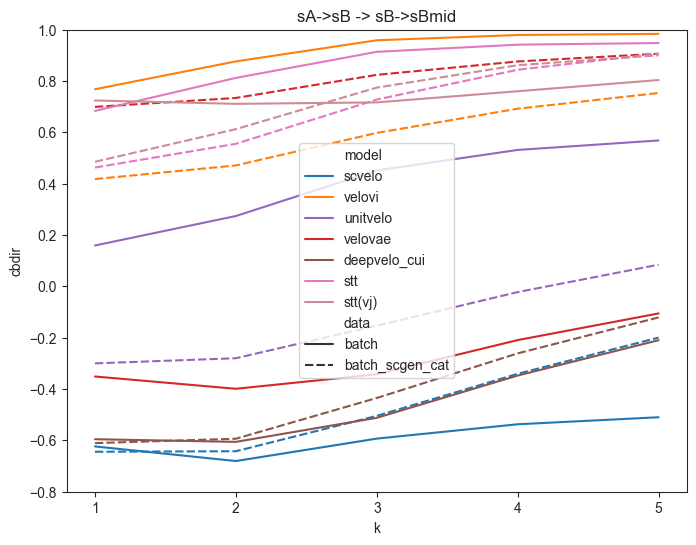

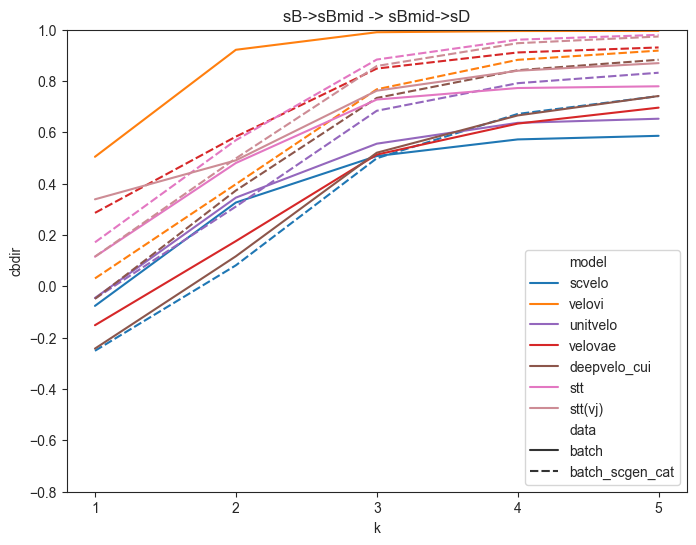

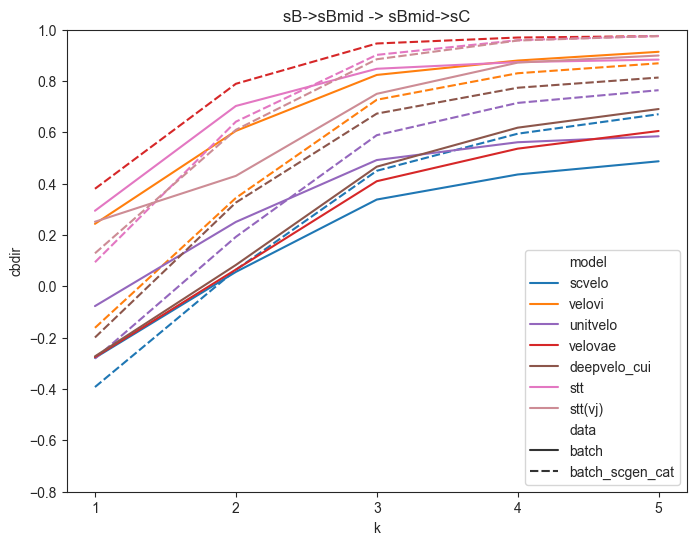

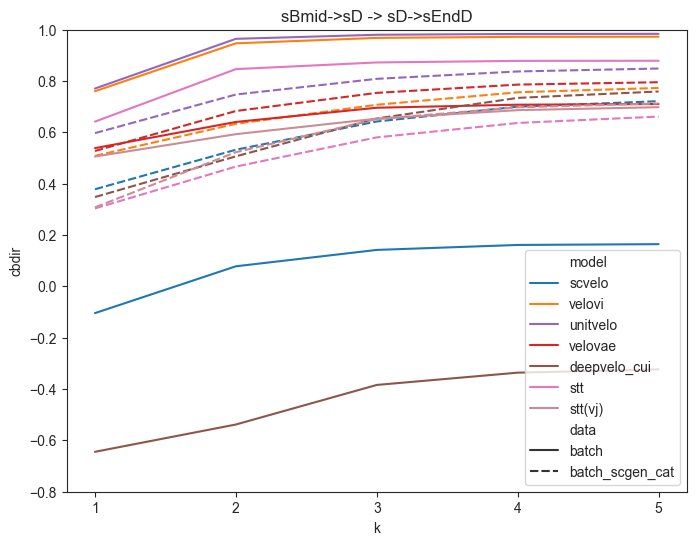

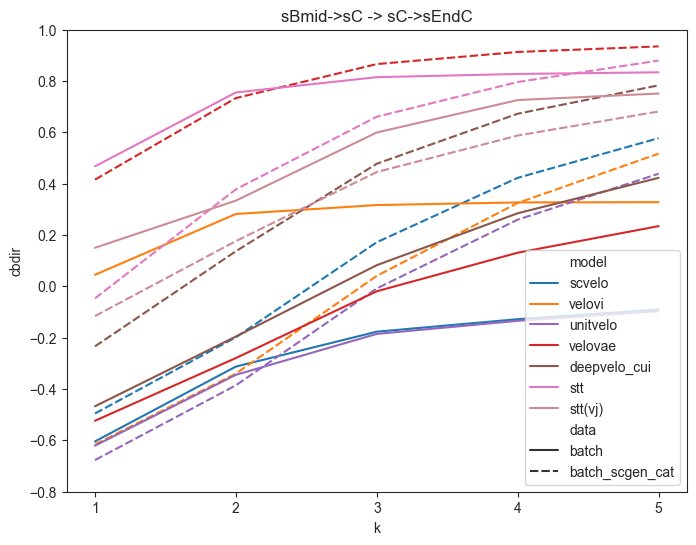

In [26]:
for key, value in results.items():
    df_list = []
    for model, metric in value.items():
        for data, cbdir in metric.items():
            for i, cbdir_i in enumerate(cbdir):
                df_list.append({'k': i+1, 'model': model, 'cbdir': cbdir_i, 'data': data.replace('simulate/', '')})
    df = pd.DataFrame(df_list)
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=df, x='k', y='cbdir', hue='model', style='data', palette=model_colors)
    plt.xticks(range(1, k+1))
    plt.ylim(-0.8, 1)
    plt.title(key)
    plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
    plt.show()